# S&P 500 Equity Option Analytics: Feature Engineering

Most feature matrices in this book are built from one market's own history. This one is built
from two. The option market quotes a distribution for a name's coming month, and the share price
says what the equity market pays for it today; the claim under test is that the disagreement
between them ranks names against each other. That makes the timing contract the hard part rather
than an afterthought: a surface summary is stamped at the close it summarizes, the share price
*is* the decision snapshot, and the two therefore become knowable at different moments. This
notebook states that difference in the register, applies it once, and then shows that withholding
the holdout leaves every value unchanged.

## Learning objectives

- Separate what the surface *says* from where it stands against its own history, and see why only
  the second is comparable across names of very different volatility
- Apply an information lag to one source and not the other, from a single declared number
- Build every trailing window inside the **security** rather than the ticker, on prices that
  carry their own splits and dividends, and measure what each of those two choices is worth
- Show that a matrix rebuilt without the holdout reproduces the values on the rows it shares

## Book reference, prerequisites and artifacts

Chapter 8, Sections 8.1-8.6. Reads the daily IV surface summary via `load_sp500_options_surface()`
and daily equity bars via `load_sp500_daily_bars()`, plus `config/setup.yaml`. Writes
`features/financial.parquet` with a `.digest.json` sidecar, read by
[`04_model_based_features`](04_model_based_features.ipynb), which fits GJR-GARCH on top of it to
turn the backward-looking variance risk premium into a forward-looking one, and by
[`05_evaluation`](05_evaluation.ipynb), which tests fold by fold whether any of it predicts.
[`02_labels`](02_labels.ipynb) supplies the forward returns those two stages score against.

In [1]:
"""S&P 500 Equity Option Analytics: Feature Engineering."""

import warnings
from datetime import date

import polars as pl
import yaml
from ml4t.engineer.features.ml import percentile_rank_features
from ml4t.engineer.features.volatility.garman_klass_volatility import garman_klass_volatility

from case_studies.utils.artifact_digest import value_digest, write_artifact
from case_studies.utils.feature_engineering import (
    EPS,
    assert_values_agree,
    assign_families,
    cross_sectional_percentile,
    families_from_config,
    family_coverage,
    plot_coverage_through_time,
    plot_cross_sectional_dispersion,
    plot_feature_distributions,
    plot_persistence,
    plot_redundancy_clusters,
    plot_timing_contract,
    register_frame,
    rolling_zscore,
    trailing_return,
    trailing_volatility,
    warmup_audit,
)
from data import load_sp500_daily_bars, load_sp500_options_surface
from utils.paths import display_path, get_case_study_dir

warnings.filterwarnings("ignore")

CASE_DIR = get_case_study_dir("sp500_equity_option_analytics")
FEATURES_DIR = CASE_DIR / "features"

Production runs the full window both sources cover and CI overrides `START_DATE` to shorten it.
There is no symbol cap in the way the other case studies carry one: every percentile below is
taken across the cross-section quoted that day, so capping the universe changes the value of a
feature rather than the size of the run.

In [2]:
START_DATE = "2017-01-01"
END_DATE = "2021-12-31"

## Configuration

Every window, the ranked-column mapping, the information lag, the decision horizon and the
holdout boundary are declared in `config/setup.yaml` and bound here. A window retyped in the
notebook is a second source of truth for a decision the register, the warmup assertion and the
timing figure all have to agree on. The horizon fixes how far the persistence figure has to look,
because a feature has to hold its ordering for at least one decision cycle to be tradable at this
cadence.

In [3]:
setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())
FEATURES = setup["features"]
FAMILIES = families_from_config(setup)
WINDOWS = FEATURES["windows"]
RANKED = FEATURES["ranked"]
SURFACE = FEATURES["surface"]
PERIODS_PER_YEAR = setup["evaluation"]["periods_per_year"]
DECISION_CYCLE = int(setup["labels"]["horizons"][setup["labels"]["primary"]].rstrip("Dd"))
IV_LAG = int(setup["decision"]["iv_feature_lag"].split("_")[0])
HOLDOUT_START = date.fromisoformat(setup["evaluation"]["holdout_start"])

# The entity every trailing window is taken inside, and the key the matrix is written on.
ENTITY = "sec_id"
PANEL_KEY = ["timestamp", "symbol"]

print(f"{len(FAMILIES)} declared families, decision cycle {DECISION_CYCLE} sessions")
print(f"Option-derived families lag {IV_LAG} session; holdout starts {HOLDOUT_START}")

8 declared families, decision cycle 5 sessions
Option-derived families lag 1 session; holdout starts 2021-01-01


## A. What the thesis says should carry information

The hypothesis is cross-sectional and it is about a disagreement: among the S&P 500 names that
have a listed option market, the ones whose options are priced richly against what their shares
go on to do can be ranked against each other, and that ranking pays over the following week.
Three things follow from it.

The **carrier** is the variance risk premium - implied volatility against the volatility the
share actually realized. It is the only family here that reads both markets in one number, and it
is the treatment `config/setup.yaml` names for the causal stage. The surface families around it
say where that premium is coming from: the level of implied volatility, its motion, and the shape
of the surface across strike and across horizon.

The **conditioning** is what the equity market has been doing on its own. Realized volatility and
the asymmetry of the realized path describe the state a signal is read in, which is why the
register marks them `state` rather than `signal`. Equity momentum is a signal, and it is here for
an adversarial reason rather than an additive one: it is the cheap price-based ranking the
option-derived families would have to displace to be worth their data cost.

The **frame** is what makes the timing contract unusual. Two sources arrive at the same decision
and they are not knowable at the same instant. The surface summary is stamped at the close it
summarizes and is not published in time to act on that close, so every option-derived family
carries a one-session lag; the share price at the close *is* the snapshot the decision is taken
at, so the equity families carry none. The register records that as a per-family `lag`, and
Section D draws it.

The register is declared in `config/setup.yaml`, one row per family.

In [4]:
register_frame(FAMILIES).select(["family", "role", "inputs", "lookback (bars)", "lag (bars)"])

family,role,inputs,lookback (bars),lag (bars)
str,str,str,i64,i64
"""cross-sectional rank""","""signal""","""the eight level and dynamics c…",252,1
"""implied volatility level""","""signal""","""daily IV surface summary, delt…",1,1
"""implied volatility dynamics""","""signal""","""at-the-money 30-day implied vo…",252,1
"""skew and term structure""","""signal""","""25-delta put and call IV, and …",63,1
"""variance risk premium""","""signal""","""at-the-money implied volatilit…",63,1
"""realized volatility""","""state""","""split- and dividend-adjusted O…",63,0
"""equity momentum""","""signal""","""split- and dividend-adjusted c…",252,0
"""surface quality""","""state""","""bid-ask spread and solver conv…",1,1


## B. Inputs and their observability

Two loaders, and the observability question is different for each.

The **surface summary** is one row per name and session, reducing that day's option chains to a
handful of quoted points: at-the-money implied volatility in three maturity buckets, the
25-delta put and call, the spread of the selected contract and the share of selected points whose
implied volatility solver converged. The contract behind each point is chosen by nearest delta
within a fixed days-to-expiry bucket rather than by moneyness, so the same column means the same
thing for a name whose strike ladder is coarse and one whose ladder is fine. The bucket and delta
targets are declared under `features.surface`; the selection itself lives in
`data/equities/market/sp500/materialize_options.py`.

A name has a surface row only on sessions its options actually quoted, so this panel is
**sparse in time** and it is the panel every option-derived window counts its bars in. A
252-bar percentile is 252 quoted sessions for that name, which for a thinly quoted name spans
more than a calendar year. That is stated rather than repaired: interpolating a surface onto
sessions it was not quoted on would invent the observation the feature is about.

The **equity bars** carry `open`, `high`, `low` and `close` as they printed, and `adj_factor`,
the cumulative factor that puts a price on a comparable footing with the rest of that security's
history. Multiplying gives a series in which a four-for-one split is not a three-quarter loss.
Every return and every volatility below is taken on the adjusted series, for the same reason
[`02_labels`](02_labels.ipynb) takes the label on it.

The entity a trailing window may not cross is the **security**, and the column that identifies it
is `sec_id` rather than the ticker: a ticker is reassigned after a merger or a spin-off and
`adj_factor` restarts with the new security, so a window that steps across the change reads one
company's price against another's. Both panels are keyed inside `sec_id` here and written out on
the ticker, because the downstream join is on ticker and session.

Section E measures what each of those two choices is worth on this sample.

In [5]:
bars = (
    load_sp500_daily_bars(start_date=START_DATE, end_date=END_DATE)
    .with_columns(pl.col("timestamp").cast(pl.Date))
    .with_columns(
        *[
            (pl.col(c) * pl.col("adj_factor")).alias(f"adj_{c}")
            for c in ("open", "high", "low", "close")
        ]
    )
    .sort([ENTITY, "timestamp"])
)
surface = (
    load_sp500_options_surface(start_date=START_DATE, end_date=END_DATE)
    .join(bars.select([*PANEL_KEY, ENTITY]), on=PANEL_KEY, how="inner")
    .sort([ENTITY, "timestamp"])
)
SURFACE_COLS = [c for c in surface.columns if c not in (*PANEL_KEY, ENTITY)]

print(f"{len(bars):,} equity bars over {bars[ENTITY].n_unique()} securities")
print(f"{len(surface):,} surface rows over {surface[ENTITY].n_unique()} securities")
print(f"{surface['timestamp'].min()} to {surface['timestamp'].max()}")
print(f"maturity buckets {SURFACE['dte_buckets']}, delta targets {SURFACE['delta_targets']}")

635,703 equity bars over 629 securities
530,503 surface rows over 624 securities
2017-01-03 to 2021-12-31
maturity buckets {'7d': [5, 10], '30d': [25, 35], '90d': [80, 110]}, delta targets {'atm': 0.5, '25d': 0.25, '10d': 0.1}


## C. Feature construction, one subsection per family

### C.1 The lag, and one null policy for the surface

The lag is applied **first**, to the loaded columns, and everything downstream is built from the
lagged series. Lagging the finished dynamics instead puts the correctness of every later column
in the hands of whoever remembers to add it to the shift list, and a column added afterwards is
then silently unlagged.

A shifted surface leaves a hole wherever a name did not quote, so a value is carried forward for
a bounded number of quoted sessions and then allowed to lapse. This is the notebook's **one**
null policy: it is applied here, once, to the surface alone, and Section F1 shows what it leaves.
The equity panel needs none - a listed share prints a close every session it trades.

In [6]:
def lag_surface(df: pl.DataFrame) -> pl.DataFrame:
    """Shift every quoted column by the declared lag, then carry it a bounded distance."""
    return df.sort([ENTITY, "timestamp"]).with_columns(
        pl.col(c).shift(IV_LAG).forward_fill(WINDOWS["iv_forward_fill"]).over(ENTITY)
        for c in SURFACE_COLS
    )

### C.2 Implied volatility dynamics

The level of implied volatility is not comparable across names: a utility at twenty and a
semiconductor at fifty are not a ranking. What is comparable is where each name sits against its
**own** recent history, so the level is carried alongside its first difference, its change over
one week and one month, its trailing z-score at two windows, and its trailing percentile. The
percentile is `percentile_rank_features` from `ml4t.engineer.features.ml` - a rolling rank of the
current value among the window's own values. A min-max position between the window's extremes is
a different statistic that moves with a single outlier at either end.

The skew and term-structure columns arrive already shaped as differences and ratios between
surface points, so what is added here is only the motion: the daily change in the risk reversal
and in the term ratio, and a z-score for each against its own recent history.

In [7]:
def surface_dynamics(df: pl.DataFrame) -> pl.DataFrame:
    """Change, momentum, trailing z-score and trailing percentile of the quoted surface."""
    atm, skew, term = "iv_30_atm", "skew_rr_30_25d", "term_ratio_atm"
    return df.with_columns(
        *[(pl.col(c) - pl.col(c).shift(1).over(ENTITY)).alias(f"d_{c}") for c in (atm, skew, term)],
        *[
            (pl.col(atm) - pl.col(atm).shift(w).over(ENTITY)).alias(f"iv_mom_{w}d")
            for w in WINDOWS["iv_momentum"]
        ],
        *[rolling_zscore(atm, w, ENTITY).alias(f"iv_30_atm_z_{w}") for w in WINDOWS["iv_zscore"]],
        rolling_zscore(skew, WINDOWS["skew_zscore"], ENTITY).alias(
            f"skew_rr_z_{WINDOWS['skew_zscore']}"
        ),
        rolling_zscore(term, WINDOWS["term_zscore"], ENTITY).alias(
            f"term_ratio_z_{WINDOWS['term_zscore']}"
        ),
        percentile_rank_features(atm, windows=[WINDOWS["iv_percentile"]])[
            f"rank_{WINDOWS['iv_percentile']}"
        ]
        .over(ENTITY)
        .alias(f"iv_30_atm_pct_{WINDOWS['iv_percentile']}"),
    )

### C.3 Realized volatility and momentum from the equity path

Both families are computed on the **full** bar panel, before the surface decides which rows
survive. A trailing mean is a property of the security's whole history and has to read every
session it traded, including the sessions on which its options did not quote. Joining first and
then computing makes a one-year volatility average across a gap the security never had.

`trailing_return` and `trailing_volatility` are the shared primitives, so a return and a
volatility mean the same thing here as in the other case studies - the volatility is the
annualized standard deviation of **log** returns, not of simple ones. Garman-Klass comes from
`ml4t.engineer.features.volatility.garman_klass_volatility`, and it is carried beside the
close-to-close estimator because an overnight gap is a real move that close-to-close cannot see.
Skip-month momentum runs from $t-252$ to $t-21$ and divides prices rather than subtracting
returns, because returns compound. Risk-adjusted momentum divides the quarterly return by the
quarterly volatility already computed rather than by a second private copy of it.

In [8]:
def equity_features(df: pl.DataFrame) -> pl.DataFrame:
    """Realized volatility, its own dispersion and asymmetry, and the momentum ladder."""
    vol_short, vol_long = WINDOWS["realized_vol"]
    log_ret = pl.col("adj_close").log().diff().over(ENTITY)
    df = df.with_columns(log_ret.alias("_log_ret")).with_columns(
        *[
            trailing_volatility("_log_ret", w, ENTITY, periods_per_year=PERIODS_PER_YEAR).alias(
                f"rv_{w}"
            )
            for w in WINDOWS["realized_vol"]
        ],
        *[trailing_return("adj_close", w, ENTITY).alias(f"mom_{w}d") for w in WINDOWS["momentum"]],
        garman_klass_volatility(
            "adj_open",
            "adj_high",
            "adj_low",
            "adj_close",
            period=WINDOWS["garman_klass"],
            trading_periods=PERIODS_PER_YEAR,
        )
        .over(ENTITY)
        .alias(f"gk_vol_{WINDOWS['garman_klass']}"),
        (
            pl.col("adj_close").shift(WINDOWS["skip_recent"]).over(ENTITY)
            / pl.col("adj_close").shift(WINDOWS["skip_start"]).over(ENTITY).clip(lower_bound=EPS)
            - 1
        ).alias("mom_skip_recent"),
    )
    standardized = pl.col("_log_ret") / pl.col(f"rv_{vol_short}").clip(lower_bound=EPS)
    return df.with_columns(
        pl.col(f"rv_{vol_short}")
        .rolling_std(WINDOWS["vol_of_vol"])
        .over(ENTITY)
        .alias(f"vol_of_vol_{WINDOWS['vol_of_vol']}"),
        standardized.pow(3)
        .rolling_mean(WINDOWS["realized_skew"])
        .over(ENTITY)
        .alias(f"realized_skew_{WINDOWS['realized_skew']}"),
        (
            pl.col(f"mom_{WINDOWS['risk_adjusted']}d")
            / pl.col(f"rv_{vol_long}").clip(lower_bound=WINDOWS["risk_adjusted_vol_floor"])
        ).alias(f"mom_risk_adj_{WINDOWS['risk_adjusted']}"),
    )


EQUITY_COLS = [
    "rv_20",
    "rv_63",
    "gk_vol_21",
    "vol_of_vol_21",
    "realized_skew_21",
    "mom_5d",
    "mom_21d",
    "mom_63d",
    "mom_126d",
    "mom_252d",
    "mom_skip_recent",
    "mom_risk_adj_63",
]

### C.4 The variance risk premium and cross-sectional position

The premium is the one number that reads both markets: the lagged at-the-money implied
volatility of the coming month against the volatility the share realized over the past month,
in volatility points, with a z-score against its own recent history beside it.

Eight of the levels above are also carried as their percentile within the decision date, because
a long-short book can only act on relative standing. `cross_sectional_percentile` takes the rank
over one more than the count, which keeps the top name off the boundary and makes the mapping a
percentile into $(0, 100)$ rather than a rank divided by its own maximum. The partition is the
decision timestamp alone: every row here is one name at one decision, so there is no second key
to rank within.

In [9]:
def premium_and_ranks(df: pl.DataFrame) -> pl.DataFrame:
    """The IV-RV spread, its z-score, and the within-date percentiles of eight levels."""
    vol_short = WINDOWS["realized_vol"][0]
    # The join above carries no ordering guarantee, and a rolling window reads the rows in the
    # order it finds them. Sorting here is what makes the z-score below a trailing statistic
    # rather than one taken over an arbitrary permutation of each security's history.
    df = (
        df.sort([ENTITY, "timestamp"])
        .with_columns((pl.col("iv_30_atm") - pl.col(f"rv_{vol_short}")).alias("ivrv_spread"))
        .with_columns(
            rolling_zscore("ivrv_spread", WINDOWS["vrp_zscore"], ENTITY).alias(
                f"vrp_z_{WINDOWS['vrp_zscore']}"
            )
        )
    )
    return df.with_columns(
        cross_sectional_percentile(source, "timestamp").alias(name)
        for source, name in RANKED.items()
    )

The four subsections compose into one function, which is what lets D.3 re-run the whole
construction on a shorter panel and compare. The equity families are computed on the bar panel
and joined onto the surface panel, so the matrix's universe is exactly the names that quoted
options that session - which is the eligibility rule `config/setup.yaml` declares.

In [10]:
def build_features(surface: pl.DataFrame, bars: pl.DataFrame) -> pl.DataFrame:
    """Lag, dynamics, equity families, premium and percentiles, in dependency order."""
    return (
        lag_surface(surface)
        .pipe(surface_dynamics)
        .join(
            equity_features(bars).select([*PANEL_KEY, *EQUITY_COLS]),
            on=PANEL_KEY,
            how="left",
        )
        .pipe(premium_and_ranks)
    )


built = build_features(surface, bars)
feature_cols = sorted(c for c in built.columns if c not in (*PANEL_KEY, ENTITY, "_log_ret"))
print(f"{len(built):,} rows carrying {len(feature_cols)} features")

530,503 rows carrying 45 features


## D. The timing contract

### D.1 What each construction reads

Four kinds of operation appear above. A **shift** reads exactly one earlier bar of the same
series, and it is what the information lag is. A **rolling** window - every z-score, percentile,
return, volatility and third moment - ends at its own row and reads a fixed number of that
security's own bars backward. A **contemporaneous** relation - the variance risk premium, and the
skew and term columns the loader supplies - reads two quantities stamped at the same row and no
other row at all. A **cross-sectional** statistic - the eight percentiles - is taken with
`.over("timestamp")`, so it reads every name quoted at that decision and nothing dated before or
after it.

None of the four is fitted: no bound, scaler or encoder here has parameters estimated once and
applied to every row. The one asymmetry worth naming is that the rolling windows on the surface
count **quoted** bars and those on the equity panel count **trading sessions**, because the two
panels are indexed differently; the register's lookback is in bars of the family's own frame.

### D.2 Warmup

A trailing window cannot produce a value until it has enough bars to fill. The audit checks that
length rather than describing it: a column carrying a value before its window could have filled
is reading bars that do not exist, and that is the failure it raises on.

The two audits count on different frames, and the lag is why. A surface column's window is
counted in the lagged surface panel and must clear its window **plus** the lag, because the first
bar is spent on the shift. An equity column's window is counted in the bar panel, where no lag
applies and the count is in trading sessions.

In [11]:
warmup_audit(
    lag_surface(surface).pipe(surface_dynamics),
    {
        "iv_30_atm": IV_LAG,
        "d_iv_30_atm": IV_LAG + 1,
        "iv_mom_21d": IV_LAG + WINDOWS["iv_momentum"][1],
        "iv_30_atm_z_63": IV_LAG + WINDOWS["iv_zscore"][0],
        "iv_30_atm_z_252": IV_LAG + WINDOWS["iv_zscore"][1],
        "iv_30_atm_pct_252": IV_LAG + WINDOWS["iv_percentile"],
        "skew_rr_z_63": IV_LAG + WINDOWS["skew_zscore"],
    },
    entity=ENTITY,
)

column,declared warmup (bars),first populated bar,populated
str,i64,i64,bool
"""iv_30_atm""",1,2,true
"""d_iv_30_atm""",2,3,true
"""iv_mom_21d""",22,23,true
"""iv_30_atm_z_63""",64,64,true
"""iv_30_atm_z_252""",253,253,true
"""iv_30_atm_pct_252""",253,253,true
"""skew_rr_z_63""",64,64,true


In [12]:
warmup_audit(
    equity_features(bars),
    {
        "mom_252d": WINDOWS["momentum"][-1],
        "mom_skip_recent": WINDOWS["skip_start"],
        "rv_63": WINDOWS["realized_vol"][1],
        "rv_20": WINDOWS["realized_vol"][0],
        "gk_vol_21": WINDOWS["garman_klass"],
        "realized_skew_21": WINDOWS["realized_skew"],
    },
    entity=ENTITY,
)

column,declared warmup (bars),first populated bar,populated
str,i64,i64,bool
"""mom_252d""",252,253,true
"""mom_skip_recent""",252,253,true
"""rv_63""",63,64,true
"""rv_20""",20,21,true
"""gk_vol_21""",21,21,true
"""realized_skew_21""",21,41,true


### D.3 Withholding the holdout changes nothing

Shifted, trailing, contemporaneous and within-date statistics share a property worth checking
directly: recomputed on panels that stop before the holdout, they reproduce the same values on
the rows the two builds share. A parameter fitted over a whole column does not, because
truncating the column moves the parameter and with it every row it was applied to. Comparing two
builds tests every emitted column at once and does not depend on anyone having flagged the
transform that fits. A value on one side against a null on the other counts as a difference.

In [13]:
BEFORE = pl.col("timestamp") < HOLDOUT_START
seal = assert_values_agree(
    built.filter(BEFORE),
    build_features(surface.filter(BEFORE), bars.filter(BEFORE)),
    columns=feature_cols,
    keys=PANEL_KEY,
)
seal.filter(pl.col("column").is_in(["iv_30_atm_pct_252", "vrp_z_63", "iv_rank"]))

column,rows compared,null only on one side,max abs difference
str,i64,i64,f64
"""iv_30_atm_pct_252""",423642,0,0.0
"""iv_rank""",423642,0,0.0
"""vrp_z_63""",423642,0,0.0


## E. Matrix assembly and coverage

The panel key is `timestamp` + `symbol`. Everything the two loaders supplied that is not itself a
feature is excluded: the OHLC set, volume, the adjustment factors, and `sec_id`, which is the
entity every window was taken inside but not part of the key, because the downstream join is on
ticker and session. The log return goes with them, as the intermediate the volatility family
standardizes rather than a feature.

The two choices Section B made are measured here rather than asserted. Building the returns on
the printed close instead of the adjusted one changes a one-session return by more than one
percent on some rows, and every trailing window containing such a row inherits it; taking the
windows inside the ticker instead of the security lets a window span two different companies.
Neither is visible in the matrix once it is built, which is why the count is printed.

In [14]:
features = built.select([*PANEL_KEY, *feature_cols]).sort(PANEL_KEY)
assert features.select(PANEL_KEY).is_duplicated().sum() == 0, "duplicate panel key"
assignment = assign_families(feature_cols, FAMILIES)
register_frame(FAMILIES, feature_cols).select(["family", "columns", "role", "representation"])

family,columns,role,representation
str,i64,str,str
"""cross-sectional rank""",8,"""signal""","""percentile within the date, in…"
"""implied volatility level""",5,"""signal""","""annualized implied volatility,…"
"""implied volatility dynamics""",6,"""signal""","""first difference, multi-sessio…"
"""skew and term structure""",10,"""signal""","""differences and ratios between…"
"""variance risk premium""",2,"""signal""","""spread in volatility points an…"
"""realized volatility""",5,"""state""","""annualized standard deviation,…"
"""equity momentum""",7,"""signal""","""simple return at five horizons…"
"""surface quality""",2,"""state""","""relative spread, and the share…"


In [15]:
raw = bars.with_columns(
    pl.col("close").pct_change().over(ENTITY).alias("_raw"),
    pl.col("adj_close").pct_change().over(ENTITY).alias("_adj"),
).with_columns(((pl.col("_raw") - pl.col("_adj")).abs() > 0.01).cast(pl.Int32).alias("_gap"))
N_ADJUSTED = int(raw["_gap"].sum())
N_WINDOW_HIT = int(
    (raw.select(pl.col("_gap").rolling_sum(WINDOWS["momentum"][-1]).over(ENTITY))["_gap"] > 0).sum()
)
N_TICKER_CROSS = int(
    bars.sort(["symbol", "timestamp"])
    .select((pl.col(ENTITY) != pl.col(ENTITY).shift(1).over("symbol")).fill_null(False))
    .to_series()
    .sum()
)

The matrix carries **45 features** on **530,503 rows** across **633 names**, from **2017-01-03**
to **2021-12-31**, one row per name and quoted session. Corporate actions move a one-session
return by more than a percentage point on **1,069** security-sessions, and **14.5%** of the bar
panel has a one-year window containing at least one of them. That is the share of the momentum
ladder the adjusted series changes. Fifteen ticker reassignments are kept out of every window by
keying inside the security instead.

In [16]:
sessions = bars["timestamp"].unique().sort()
WARMUP_END = sessions[max(f.lookback + f.lag for f in FAMILIES)]
coverage = family_coverage(features, assignment, every="1mo")
print(
    f"{len(feature_cols)} features, {len(features):,} rows, {features['symbol'].n_unique()} names"
)
print(f"{features['timestamp'].min()} to {features['timestamp'].max()}, warmup ends {WARMUP_END}")
print(
    f"{N_ADJUSTED:,} adjusted sessions; {N_WINDOW_HIT / len(bars):.1%} of bars carry one in a "
    "one-year window"
)
print(f"{N_TICKER_CROSS} ticker reassignments the security key keeps windows out of")

45 features, 530,503 rows, 633 names
2017-01-03 to 2021-12-31, warmup ends 2018-01-04
1,069 adjusted sessions; 14.5% of bars carry one in a one-year window
15 ticker reassignments the security key keeps windows out of


### F1. Coverage through time

Below the boundary the long-window families are empty by construction - a one-year percentile
cannot exist until a name has quoted for a year - so the axis runs the full range rather than the
top percent it would need for a matrix that is dense throughout. The steady gap between the
option-derived families and the equity ones after the boundary is the null policy of C.1: a name
that stops quoting for longer than the carry-forward allows drops out of the surface families and
stays in the price ones.

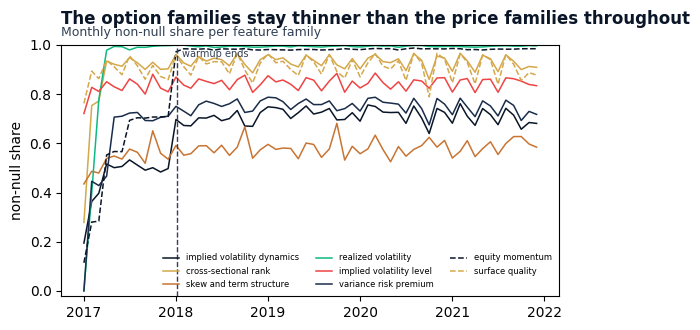

In [17]:
plot_coverage_through_time(
    coverage,
    warmup_boundary=WARMUP_END,
    title="The option families stay thinner than the price families throughout",
    subtitle="Monthly non-null share per feature family",
    alt=(
        "Line chart of non-null share by feature family by month, on a y-axis running from zero "
        "to one. Realized volatility jumps to one within the first months and stays flat there. "
        "Equity momentum climbs through 2017 and steps up to one at the marked warmup boundary "
        "at the start of 2018. Every option-derived family settles below both of them and stays "
        "there for the rest of the sample: surface quality and the cross-sectional ranks around "
        "0.9, the implied volatility level a little under that, the implied volatility dynamics "
        "and the variance risk premium around 0.7, and skew and term structure lowest at "
        "roughly 0.6. All of them are ragged month to month where the two price families are "
        "smooth."
    ),
)

### F4. The timing contract

The lag is the more consequential half of the contract here and the half the figure cannot
resolve: a one-bar gap against a lookback of up to a year is thinner than the line that draws
it, so six of the eight bars appear to touch the decision line when only two of them do. The
register is what the warmup audit above asserted against, and it is where the lag is legible.
What the bars do show is the span each family reads, which sets where the warmup boundary in F1
falls, and that two of the families read the current bar and nothing else.

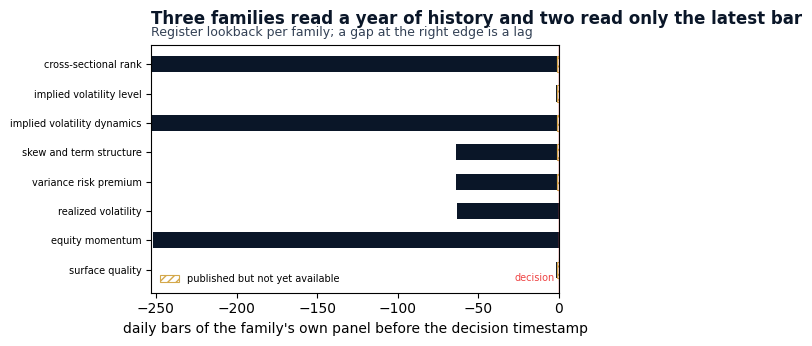

In [18]:
plot_timing_contract(
    FAMILIES,
    bar_unit="daily bars of the family's own panel",
    title="Three families read a year of history and two read only the latest bar",
    subtitle="Register lookback per family; a gap at the right edge is a lag",
    alt=(
        "Horizontal bars, one per feature family, each extending leftward from the decision "
        "line at zero by that family's lookback. The cross-sectional ranks, the implied "
        "volatility dynamics and equity momentum run the full width of the axis to minus 252 "
        "bars. Skew and term structure, the variance risk premium and realized volatility reach "
        "about minus 63. The implied volatility level and the surface quality family have a "
        "lookback of one bar and are drawn as a sliver at the right edge, the second of them "
        "behind the decision label. The one-bar information lag the register carries for the six "
        "option-derived families is too narrow to be visible at this scale."
    ),
)

## F. What the features look like

Four properties decide whether this matrix can be used at all: the scale each feature arrives on,
whether the cross-section disagrees enough to rank on, how much of the set is one ordering under
several names, and how long a value lasts. `05_evaluation` is where the matrix is tested fold by
fold for whether any of it predicts.

### F2. Feature distributions

The implied-volatility family is shown on the scales a reader would judge it: the level, its
daily change, its motion over a month, how far it sits from its own history at two windows, and
its trailing percentile. The same quantity looks completely different in level and in percentile
form, which is the point of carrying both.

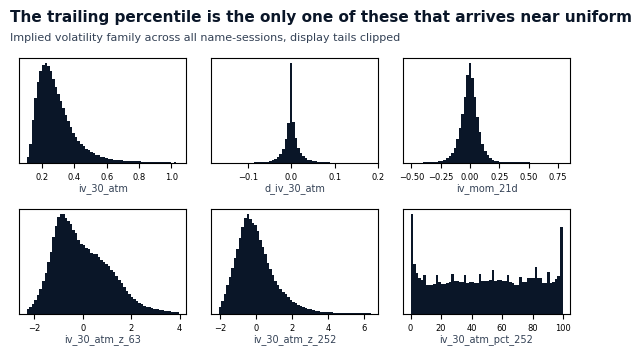

In [19]:
plot_feature_distributions(
    features,
    [
        "iv_30_atm",
        "d_iv_30_atm",
        "iv_mom_21d",
        "iv_30_atm_z_63",
        "iv_30_atm_z_252",
        "iv_30_atm_pct_252",
    ],
    title="The trailing percentile is the only one of these that arrives near uniform",
    subtitle="Implied volatility family across all name-sessions, display tails clipped",
    alt=(
        "Six histograms in two rows. At-the-money implied volatility is right-skewed, peaking "
        "near a quarter with a long tail toward one. Its daily change is an extremely narrow "
        "spike at zero; its one-month change is peaked at zero too but far wider, spanning "
        "about minus a half to three quarters. The two z-scores below them are broad, "
        "right-skewed bells, the shorter-window one running from about minus two to four and "
        "the longer-window one to about six. The trailing percentile is close to uniform across "
        "its range with a tall spike at each end."
    ),
)

### F3. Cross-sectional dispersion through time

A cross-sectional strategy needs the cross-section to disagree. On a date where the band narrows
to nothing there is nothing to rank, whatever the average level of the premium. This reads the
carrier - implied volatility against realized - because it is the quantity the thesis ranks on
and the treatment the causal stage estimates an effect for.

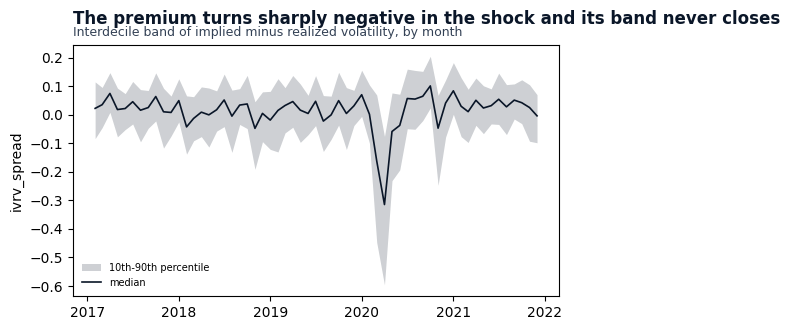

In [20]:
plot_cross_sectional_dispersion(
    features,
    "ivrv_spread",
    every="1mo",
    title="The premium turns sharply negative in the shock and its band never closes",
    subtitle="Interdecile band of implied minus realized volatility, by month",
    alt=(
        "Shaded band of the 10th to 90th percentile of the implied-minus-realized volatility "
        "spread by month, with the median drawn through it. The median sits a little above zero "
        "for most of the sample and the band runs roughly minus 0.08 to plus 0.1. In the first "
        "quarter of 2020 the median drops to about minus 0.31 and the lower edge of the band to "
        "about minus 0.6 as realized volatility overtakes implied. Through the rest of 2020 the "
        "median recovers above zero and the band stays wider than before, narrowing again "
        "during 2021. The band is never a single line."
    ),
)

### F5. Redundancy structure

Clustering on the distance $1 - |\rho|$ groups features that carry the same ordering, whatever
the sign. Above the cut two features are close enough that a linear model cannot separate their
contributions. This states the clusters. Picking one representative per cluster needs a
fold-aware criterion, which `05_evaluation` applies.

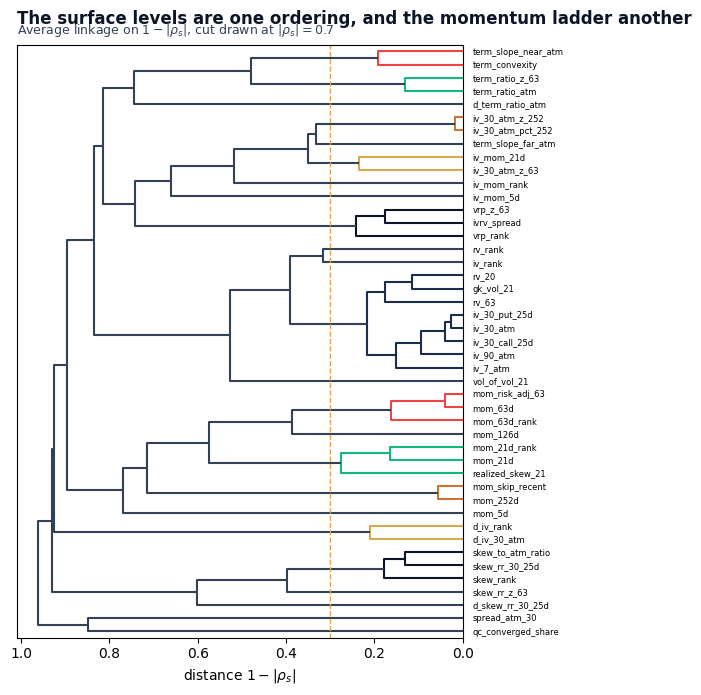

In [21]:
CUT = 0.7
clusters = plot_redundancy_clusters(
    features,
    feature_cols,
    cut=CUT,
    title="The surface levels are one ordering, and the momentum ladder another",
    subtitle=r"Average linkage on $1 - |\rho_s|$, cut drawn at $|\rho_s| = 0.7$",
    alt=(
        "Dendrogram of every feature in the matrix, distance running from one on the left to "
        "zero on the right with the cut drawn as a dashed vertical line. The tightest cluster "
        "is the three at-the-money implied volatility maturities with the two 25-delta wings, "
        "which join at almost zero distance. The two realized volatility windows and the "
        "Garman-Klass estimator form a second tight cluster, and the implied volatility and "
        "realized volatility ranks attach to that combined block. The variance risk premium, "
        "its z-score and its rank form a third. Each momentum horizon sits with its own "
        "percentile and with the risk-adjusted and skip-month forms. The term structure "
        "features form their own block and the skew features another. The two surface quality "
        "features branch off at the root, sharing an ordering with nothing else."
    ),
)

Cutting the redundancy tree at $|\rho_s| = 0.7$ leaves **24 clusters** across the **45** columns,
so nearly half the matrix repeats an ordering another column already carries.

In [22]:
print(f"{len(set(clusters.values()))} clusters over {len(feature_cols)} features at cut {CUT}")

24 clusters over 45 features at cut 0.7


### F6. Persistence and rank stability

The right-hand panel compares the ordering across consecutive **rebalances**, which
`config/setup.yaml` declares as `weekly_friday_close`. The autocorrelation on the left is of the
feature, not of the return, and it runs to four decision cycles. A feature whose value has
decayed before the next rebalance cannot support that cadence, however well it predicts on the
day it is computed. It is estimated per name on pairs of dates exactly one lag apart and
summarized by the median over names, with a bootstrap interval over names: a correlation pooled
over every name-date pair would read high whenever names sit at different levels, whether or not
any one of them persists.

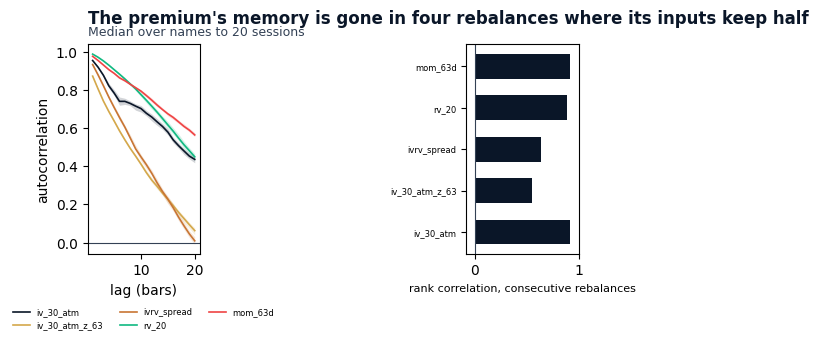

In [23]:
DECISION_DATES = (
    features.group_by(pl.col("timestamp").dt.truncate("1w"))
    .agg(pl.col("timestamp").max().alias("decision"))["decision"]
    .sort()
    .to_list()
)

plot_persistence(
    features,
    ["iv_30_atm", "iv_30_atm_z_63", "ivrv_spread", "rv_20", "mom_63d"],
    entity="symbol",
    max_lag=4 * DECISION_CYCLE,
    decision_dates=DECISION_DATES,
    title="The premium's memory is gone in four rebalances where its inputs keep half",
    subtitle=f"Median over names to {4 * DECISION_CYCLE} sessions",
    alt=(
        "Two panels. On the left, autocorrelation against lag in bars: all five series start "
        "near one. The quarterly return decays slowest and is still near 0.57 at twenty "
        "sessions; the realized volatility and the implied volatility level are both near 0.45 "
        "there. The implied volatility z-score and the implied-minus-realized spread decay much "
        "faster and reach nearly zero by twenty sessions, the spread the lower of the two. The "
        "bootstrap ribbon is narrow enough to be hard to see except around the implied "
        "volatility level. On the right, the cross-sectional rank correlation between "
        "consecutive weekly rebalances: the implied volatility level and the quarterly return "
        "are highest at about 0.9, the realized volatility just below them, the "
        "implied-minus-realized spread about 0.65 and the z-score lowest at about 0.55."
    ),
)

## G. Emit

The parquet is written with a sidecar recording the digest of its values, its row count and key
columns, and the digest of what it was built from. This stage reads no upstream case-study
artifact, so the sidecar records the two loaded panels alone, each restricted to the columns and
window actually consumed - which is what answers "which market-data vintage produced these
values". The digest is computed over content rather than file bytes, so row order and parquet
metadata leave it alone and any feature value moves it. That is the property the registry's own
hashes lack: a feature-set *name* reaches the registry, a feature-set *value* does not.

In [24]:
record = write_artifact(
    features,
    FEATURES_DIR / "financial.parquet",
    keys=PANEL_KEY,
    written_by="case_studies/sp500_equity_option_analytics/03_financial_features.py",
    inputs={
        "load_sp500_daily_bars": value_digest(
            bars.select([*PANEL_KEY, ENTITY, "open", "high", "low", "close", "adj_factor"])
        ),
        "load_sp500_options_surface": value_digest(surface.select([*PANEL_KEY, *SURFACE_COLS])),
    },
)
print(f"Wrote {display_path(FEATURES_DIR / 'financial.parquet')}, digest {record['digest']}")

Wrote case_studies/sp500_equity_option_analytics/features/financial.parquet, digest bae17bcd170c861f


## Key takeaways

- **State the timing contract before writing the feature.** The register fixes each family's
  lookback and lag in the configuration, and the warmup assertion, the timing figure and the
  review a reader can run all read those numbers rather than re-deriving them from the code.
- **Two sources means two observability rules, applied once each.** The surface is knowable a
  session after the close it summarizes and the share price is the snapshot itself; lagging the
  loaded columns rather than the finished ones is what stops a column added later from being
  silently unlagged.
- **Match the price series and the entity to the question.** Returns need prices that carry their
  own splits and dividends, and windows need the security rather than the ticker. Section E
  measures both, because neither is visible in the matrix once it is built.
- **Test the seal by construction, not by inspection.** Rebuilding the panel with later dates
  withheld and comparing values catches any transform that fits across the sample, including the
  ones nobody thought to flag.
- **Read the matrix before modelling it.** Distribution, dispersion, redundancy and decay each
  rule out a use: a feature with no cross-sectional spread cannot rank, and one whose ordering
  decays inside the rebalance cycle cannot be traded at that cadence.

### Known limitations

- The surface panel is sparse in time, so an option-derived window counts quoted sessions and an
  equity window counts trading sessions. The two are the same for a continuously quoted name and
  diverge for a thinly quoted one, and the register's lookback is in bars of its own panel.
- The carry-forward in C.1 makes a value up to its limit stale rather than missing. It is
  backward-looking, so it cannot leak, but a stale surface reads as an unchanged one and the
  surface-quality family is the only thing that hints at it.
- The premium compares a forward-looking implied month against a backward-looking realized one.
  `04_model_based_features` replaces the second half with a conditional forecast, which is what
  makes the two halves comparable.
- Every feature here is a rule written in advance. `04_model_based_features` adds the features
  that are themselves model outputs, where the rule is estimated from the data.